In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:

import os

input_dir = "/content/drive/MyDrive/medassist/SkinModel"
os.chdir(input_dir)
skin_data_path = os.path.join(input_dir, "SkinData.zip")
extract_path = ""

class_names_skin = ['akiec', 'bcc','bkl','df','mel','nv','vasc']



In [3]:

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder


In [4]:

!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 8.4 MB/s eta 0:00:00


In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split
import optuna
from optuna.trial import TrialState
import pickle
import json
from PIL import Image
import glob
from collections import defaultdict
import warnings
import random
warnings.filterwarnings('ignore')


In [6]:
import zipfile
from pathlib import Path


In [7]:

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


In [8]:

print("=== Skin Disease Classification AI System ===")
print("Hardware Check:")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


=== Skin Disease Classification AI System ===
Hardware Check:
CUDA Available: True
GPU Device: Tesla T4
GPU Memory: 14.7 GB


In [9]:
def LoadFromZipFile(zipPath):
  zip_path = zipPath  # <-- Change this to your ZIP file path
  zip_filename = Path(zip_path).stem
  extract_path_base = "/content/dataset"
  global extract_path
  # 3. Unzip the file
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path_base)

  #print(f"Extracted to: {extract_path}")

  # 4. Check contents

  extract_path = os.path.join(extract_path_base, zip_filename)
  for classname in class_names_skin:
    class_names_skin_path = os.path.join(extract_path, classname)
    print(f"class_names_skin_path = {class_names_skin_path}")
    print(f"Found {len(os.listdir(class_names_skin_path))} images in {class_names_skin_path}")



In [10]:
LoadFromZipFile(skin_data_path)



class_names_skin_path = /content/dataset/SkinData/akiec
Found 4009 images in /content/dataset/SkinData/akiec
class_names_skin_path = /content/dataset/SkinData/bcc
Found 4000 images in /content/dataset/SkinData/bcc
class_names_skin_path = /content/dataset/SkinData/bkl
Found 4000 images in /content/dataset/SkinData/bkl
class_names_skin_path = /content/dataset/SkinData/df
Found 4010 images in /content/dataset/SkinData/df
class_names_skin_path = /content/dataset/SkinData/mel
Found 4000 images in /content/dataset/SkinData/mel
class_names_skin_path = /content/dataset/SkinData/nv
Found 4001 images in /content/dataset/SkinData/nv
class_names_skin_path = /content/dataset/SkinData/vasc
Found 4001 images in /content/dataset/SkinData/vasc



# 1. ENHANCED DATASET SETUP WITH ON-THE-FLY AUGMENTATION


In [11]:

class SkinDiseaseDataset(Dataset):
    """Enhanced Dataset for Skin Disease Classification with on-the-fly augmentation"""

    def __init__(self, root_dir, transform=None, augment_transform=None, class_names=None,
                 use_augmentation=True, augmentation_factor=2):
        """
        Args:
            root_dir: Path to the dataset
            transform: Transform for original images (normalization, resize)
            augment_transform: Transform for augmented images (includes augmentation)
            class_names: List of class names
            use_augmentation: Whether to include augmented images
            augmentation_factor: How many augmented versions per original image
        """
        self.root_dir = root_dir
        self.transform = transform
        self.augment_transform = augment_transform
        self.use_augmentation = use_augmentation
        self.augmentation_factor = augmentation_factor

        self.images = []
        self.labels = []
        self.is_augmented = []  # Track which samples are augmented

        self.class_names = class_names_skin

        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.class_names)}


        print(f"Loading dataset from: {root_dir}")
        print(f"Classes: {self.class_names}")
        print(f"Augmentation enabled: {use_augmentation}")
        if use_augmentation:
            print(f"Augmentation factor: {augmentation_factor}")

        # Load original images first
        original_images = []
        original_labels = []

        for class_name in self.class_names:
            class_dir = os.path.join(root_dir, class_name)
            if os.path.exists(class_dir):
                class_images = glob.glob(os.path.join(class_dir, "*.jpg"))
                print(f"Found {len(class_images)} images in {class_name}")

                for img_path in class_images:
                    original_images.append(img_path)
                    original_labels.append(self.class_to_idx[class_name])
            else:
                print(f"Warning: Directory {class_dir} not found!")

        # Add original images
        self.images.extend(original_images)
        self.labels.extend(original_labels)
        self.is_augmented.extend([False] * len(original_images))

        # Add augmented images (references to originals with augmentation flag)
        if use_augmentation and augment_transform is not None:
            for _ in range(augmentation_factor):
                self.images.extend(original_images)
                self.labels.extend(original_labels)
                self.is_augmented.extend([True] * len(original_images))

        print(f"Total samples (original + augmented): {len(self.images)}")
        print(f"Original images: {len(original_images)}")
        if use_augmentation:
            print(f"Augmented images: {len(original_images) * augmentation_factor}")

        class_distribution = {}
        for i, class_name in enumerate(self.class_names):
            count = self.labels.count(i)
            class_distribution[class_name] = count
        print(f"Class distribution (total): {class_distribution}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        is_augmented = self.is_augmented[idx]

        # Load image
        try:
            image = Image.open(img_path).convert('RGB')

            # Apply appropriate transform
            if is_augmented and self.augment_transform is not None:
                # Apply augmentation transform (includes augmentation + normalization)
                image = self.augment_transform(image)
            elif self.transform is not None:
                # Apply standard transform (resize + normalization only)
                image = self.transform(image)

            return image, label

        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a black image if loading fails
            image = Image.new('RGB', (224, 224), (0, 0, 0))
            if self.transform:
                image = self.transform(image)
            return image, label


In [12]:


def create_enhanced_data_transforms():
    """Create enhanced data transforms for original and augmented images"""

    # Standard transform for original images (no augmentation)
    standard_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Augmentation transforms for augmented images
    augment_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        # Data augmentation techniques
        transforms.RandomRotation(degrees=15),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        # Convert to tensor and normalize
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Validation/test transforms (no augmentation)
    val_test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return standard_transforms, augment_transforms, val_test_transforms



In [13]:

def create_enhanced_datasets_and_loaders(data_dir, batch_size=32, train_ratio=0.7, val_ratio=0.15,
                                       augmentation_factor=2):
    """Create enhanced train, validation, and test datasets with on-the-fly augmentation"""

    print("=== Creating Enhanced Datasets with On-the-fly Augmentation ===")

    # Get transforms
    standard_transforms, augment_transforms, val_test_transforms = create_enhanced_data_transforms()

    # Create training dataset with augmentation
    train_dataset_full = SkinDiseaseDataset(
        data_dir,
        transform=standard_transforms,
        augment_transform=augment_transforms,
        use_augmentation=True,
        augmentation_factor=augmentation_factor
    )

    # Create validation and test datasets (no augmentation)
    val_test_dataset = SkinDiseaseDataset(
        data_dir,
        transform=val_test_transforms,
        use_augmentation=False
    )

    # Calculate split sizes for original dataset
    original_size = len(val_test_dataset)
    train_size = int(train_ratio * original_size)
    val_size = int(val_ratio * original_size)
    test_size = original_size - train_size - val_size

    print(f"Original dataset size: {original_size}")
    print(f"Split sizes - Train: {train_size}, Val: {val_size}, Test: {test_size}")
    print(f"Training dataset size (with augmentation): {len(train_dataset_full)}")

    # Create indices for splitting
    indices = list(range(original_size))
    np.random.shuffle(indices)

    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]

    # Create augmented training indices (map original indices to augmented dataset)
    augmented_train_indices = []
    images_per_original = 1 + augmentation_factor  # original + augmented versions

    for original_idx in train_indices:
        # Add all versions of this image (original + augmented)
        for version in range(images_per_original):
            augmented_idx = original_idx + (version * original_size)
            augmented_train_indices.append(augmented_idx)

    # Subset the datasets
    # Training dataset (with augmentation)
    train_dataset = SkinDiseaseDataset(
        data_dir,
        transform=standard_transforms,
        augment_transform=augment_transforms,
        use_augmentation=True,
        augmentation_factor=augmentation_factor
    )

    # Filter training dataset to include only training indices
    train_dataset.images = [train_dataset_full.images[i] for i in augmented_train_indices]
    train_dataset.labels = [train_dataset_full.labels[i] for i in augmented_train_indices]
    train_dataset.is_augmented = [train_dataset_full.is_augmented[i] for i in augmented_train_indices]

    # Validation dataset (no augmentation)
    val_dataset = SkinDiseaseDataset(data_dir, transform=val_test_transforms, use_augmentation=False)
    val_dataset.images = [val_test_dataset.images[i] for i in val_indices]
    val_dataset.labels = [val_test_dataset.labels[i] for i in val_indices]
    val_dataset.is_augmented = [val_test_dataset.is_augmented[i] for i in val_indices]

    # Test dataset (no augmentation)
    test_dataset = SkinDiseaseDataset(data_dir, transform=val_test_transforms, use_augmentation=False)
    test_dataset.images = [val_test_dataset.images[i] for i in test_indices]
    test_dataset.labels = [val_test_dataset.labels[i] for i in test_indices]
    test_dataset.is_augmented = [val_test_dataset.is_augmented[i] for i in test_indices]

    print(f"Final dataset sizes:")
    print(f"  Training: {len(train_dataset)} (includes original + {augmentation_factor}x augmented)")
    print(f"  Validation: {len(val_dataset)} (original only)")
    print(f"  Test: {len(test_dataset)} (original only)")

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                             num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                           num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, train_dataset_full.class_names




# 2. CUSTOM CNN MODEL (Enhanced version)


In [14]:

class EnhancedCustomCNN(nn.Module):
    """Enhanced Custom CNN architecture for Skin disease classification"""

    def __init__(self, num_classes=5, dropout_rate=0.5):
        super(EnhancedCustomCNN, self).__init__()

        # First Convolutional Block
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.1)
        )

        # Second Convolutional Block
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2)
        )

        # Third Convolutional Block
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.3)
        )

        # Fourth Convolutional Block
        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.4)
        )

        # Adaptive pooling to handle different input sizes
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        # Enhanced Classifier with residual connection
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(512 * 7 * 7, 2048),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(2048),
            nn.Dropout(dropout_rate * 0.8),
            nn.Linear(2048, 1024),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(1024),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate * 0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x




# 3. ENHANCED TRAINING FUNCTION WITH METRICS TRACKING


In [15]:

def train_enhanced_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                        num_epochs, device, patience=10):
    """Enhanced training function with detailed metrics tracking"""

    print(f"Training model for {num_epochs} epochs with enhanced dataset...")
    print(f"Training samples per epoch: {len(train_loader.dataset)}")
    print(f"Validation samples: {len(val_loader.dataset)}")

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    # Additional metrics tracking
    learning_rates = []
    epoch_times = []

    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0
    best_model_state = None

    import time

    for epoch in range(num_epochs):
        start_time = time.time()

        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        original_count = 0
        augmented_count = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()

            if batch_idx % 100 == 0:
                print(f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}/{len(train_loader)}, '
                      f'Loss: {loss.item():.4f}, Acc: {100.0 * train_correct / train_total:.2f}%')

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)

                val_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                val_total += target.size(0)
                val_correct += (predicted == target).sum().item()

        # Calculate averages
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Track learning rate
        current_lr = optimizer.param_groups[0]['lr']
        learning_rates.append(current_lr)

        # Track epoch time
        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print(f'Learning Rate: {current_lr:.6f}, Epoch Time: {epoch_time:.2f}s')
        print('-' * 70)

        # Learning rate scheduling
        if scheduler:
            scheduler.step(avg_val_loss)

        # Enhanced early stopping (considering both loss and accuracy)
        if avg_val_loss < best_val_loss or val_acc > best_val_acc:
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
            if val_acc > best_val_acc:
                best_val_acc = val_acc

            patience_counter = 0
            best_model_state = model.state_dict().copy()
            print(f"New best model saved! Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f'Early stopping triggered after {epoch+1} epochs')
            break

    # Load best model state
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model with Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc:.2f}%")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'learning_rates': learning_rates,
        'epoch_times': epoch_times,
        'best_val_loss': best_val_loss,
        'best_val_acc': best_val_acc
    }




# 4. REMAINING FUNCTIONS (keeping the same structure but using enhanced components)


In [16]:

def evaluate_model(model, test_loader, device, class_names):
    """Evaluate model and return comprehensive metrics"""

    print("Evaluating model on test set...")

    model.eval()
    all_predictions = []
    all_targets = []
    all_probabilities = []
    test_loss = 0.0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            test_loss += loss.item()

            probabilities = F.softmax(output, dim=1)
            _, predicted = torch.max(output, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_predictions)
    precision_macro = precision_score(all_targets, all_predictions, average='macro', zero_division=0)
    recall_macro = recall_score(all_targets, all_predictions, average='macro', zero_division=0)
    f1_macro = f1_score(all_targets, all_predictions, average='macro', zero_division=0)

    # Per-class metrics

    precision_per_class = precision_score(all_targets, all_predictions, average=None, zero_division=0)
    recall_per_class = recall_score(all_targets, all_predictions, average=None, zero_division=0)
    f1_per_class = f1_score(all_targets, all_predictions, average=None, zero_division=0)


    # Confusion matrix
    cm = confusion_matrix(all_targets, all_predictions)

    # Print results
    print(f"\n=== Enhanced Model Evaluation Results ===")
    print(f"Test Loss: {test_loss/len(test_loader):.4f}")
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Macro F1-Score: {f1_macro:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")

    print(f"\n=== Per-Class Metrics ===")
    for i, class_name in enumerate(class_names):
        print(f"{class_name}:")
        print(f"  Precision: {precision_per_class[i]:.4f}")
        print(f"  Recall: {recall_per_class[i]:.4f}")
        print(f"  F1-Score: {f1_per_class[i]:.4f}")

    return {
        'test_loss': test_loss/len(test_loader),
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class,
        'confusion_matrix': cm,
        'predictions': all_predictions,
        'targets': all_targets,
        'probabilities': all_probabilities
    }


In [17]:


def plot_enhanced_training_history(history, title="Enhanced Training History"):
    """Plot enhanced training history with additional metrics"""

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

    epochs = range(1, len(history['train_losses']) + 1)

    # Plot losses
    ax1.plot(epochs, history['train_losses'], label='Training Loss', marker='o', linewidth=2)
    ax1.plot(epochs, history['val_losses'], label='Validation Loss', marker='s', linewidth=2)
    ax1.set_title(f'{title} - Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracies
    ax2.plot(epochs, history['train_accuracies'], label='Training Accuracy', marker='o', linewidth=2)
    ax2.plot(epochs, history['val_accuracies'], label='Validation Accuracy', marker='s', linewidth=2)
    ax2.set_title(f'{title} - Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot learning rate
    ax3.plot(epochs, history['learning_rates'], label='Learning Rate', marker='d',
             color='green', linewidth=2)
    ax3.set_title(f'{title} - Learning Rate', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Learning Rate')
    ax3.set_yscale('log')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot epoch times
    ax4.plot(epochs, history['epoch_times'], label='Epoch Time', marker='x',
             color='red', linewidth=2)
    ax4.set_title(f'{title} - Training Time per Epoch', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Time (seconds)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\n=== Training Summary ===")
    print(f"Best Validation Loss: {history['best_val_loss']:.4f}")
    print(f"Best Validation Accuracy: {history['best_val_acc']:.2f}%")
    print(f"Average Epoch Time: {np.mean(history['epoch_times']):.2f} seconds")
    print(f"Total Training Time: {np.sum(history['epoch_times']):.2f} seconds")


In [18]:


def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    """Plot enhanced confusion matrix with percentages"""

    plt.figure(figsize=(12, 10))

    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Create annotations with both counts and percentages
    annotations = []
    for i in range(cm.shape[0]):
        row = []
        for j in range(cm.shape[1]):
            row.append(f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)')
        annotations.append(row)

    sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})

    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()




# 5. ENHANCED HYPERPARAMETER OPTIMIZATION


In [19]:

def enhanced_objective(trial, train_loader, val_loader, device, class_names):
    """Enhanced Optuna objective function"""

    # Suggest hyperparameters
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.3, 0.7)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    # Create model
    model = EnhancedCustomCNN(num_classes=len(class_names), dropout_rate=dropout_rate)
    model = model.to(device)

    # Create optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    # Train for fewer epochs during hyperparameter search
    history = train_enhanced_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                                 num_epochs=10, device=device, patience=5)

    # Return the best validation accuracy achieved
    return history['best_val_acc'] / 100.0  # Convert percentage to decimal



In [20]:

def optimize_enhanced_hyperparameters(train_loader, val_loader, device, class_names, n_trials=5):
    """Optimize hyperparameters using Optuna with enhanced objective"""

    print("=== Starting Enhanced Hyperparameter Optimization ===")
    print(f"Number of trials: {n_trials}")

    study = optuna.create_study(direction='maximize', study_name='enhanced_skin_disease_optimization')

    # Create objective function with fixed parameters
    def objective_wrapper(trial):
        return enhanced_objective(trial, train_loader, val_loader, device, class_names)

    study.optimize(objective_wrapper, n_trials=n_trials)

    print("=== Enhanced Hyperparameter Optimization Results ===")
    print("Best trial:")
    trial = study.best_trial
    print(f"  Best Validation Accuracy: {trial.value:.4f} ({trial.value*100:.2f}%)")
    print("  Best params:")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")

    return study.best_params




# 6. PRETRAINED MODELS WITH ENHANCED ARCHITECTURE


In [21]:

def create_enhanced_pretrained_model(model_name, num_classes, pretrained=True, dropout_rate=0.5):
    """Create enhanced pretrained models with improved classifier heads"""

    if model_name.lower() == 'resnet':
        model = models.resnet50(pretrained=pretrained)
        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_ftrs, 1024),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(1024),
            nn.Dropout(dropout_rate * 0.7),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(512, num_classes)
        )

    elif model_name.lower() == 'vgg':
        model = models.vgg16(pretrained=pretrained)
        # Replace the last classifier layer
        model.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(4096, 2048),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(2048),
            nn.Dropout(dropout_rate * 0.7),
            nn.Linear(2048, 1024),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(1024),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(1024, num_classes)
        )

    elif model_name.lower() == 'mobilenet':
        model = models.mobilenet_v2(pretrained=pretrained)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_ftrs, 1024),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(1024),
            nn.Dropout(dropout_rate * 0.7),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(512, num_classes)
        )
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    return model


In [22]:


def train_enhanced_pretrained_model(model_name, train_loader, val_loader, test_loader,
                                   device, class_names, best_params):
    """Train an enhanced pretrained model with the best hyperparameters"""

    print(f"=== Training Enhanced {model_name.upper()} Model ===")

    # Create model with enhanced architecture
    dropout_rate = best_params.get('dropout_rate', 0.5)
    model = create_enhanced_pretrained_model(model_name, len(class_names),
                                           pretrained=True, dropout_rate=dropout_rate)
    model = model.to(device)

    # Use best hyperparameters
    lr = best_params.get('lr', 1e-3)
    weight_decay = best_params.get('weight_decay', 1e-4)

    # Setup training components
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=7, factor=0.5)

    # Train model with enhanced training function
    history = train_enhanced_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                                 num_epochs=10, device=device, patience=12)

    # Evaluate model
    metrics = evaluate_model(model, test_loader, device, class_names)

    return model, history, metrics




# 7. ENHANCED MODEL TESTING AND ANALYSIS


In [23]:

def test_single_image_enhanced(model, image_path, class_names, device, transform=None):
    """Enhanced single image testing with detailed analysis"""

    if transform is None:
        _, _, transform = create_enhanced_data_transforms()

    # Load and preprocess image
    try:
        image = Image.open(image_path).convert('RGB')
        original_size = image.size
        image_tensor = transform(image).unsqueeze(0).to(device)

        # Make prediction
        model.eval()
        with torch.no_grad():
            output = model(image_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        predicted_class = class_names[predicted.item()]
        confidence_score = confidence.item()

        # Get all class probabilities
        all_probabilities = probabilities[0].cpu().numpy()

        # Get top-3 predictions
        top3_prob, top3_indices = torch.topk(probabilities, min(3, len(class_names)))
        top3_predictions = [(class_names[idx.item()], prob.item())
                           for idx, prob in zip(top3_indices[0], top3_prob[0])]

        # Calculate prediction confidence level
        if confidence_score > 0.8:
            confidence_level = "High"
        elif confidence_score > 0.6:
            confidence_level = "Medium"
        else:
            confidence_level = "Low"

        print(f"=== Enhanced Image Analysis ===")
        print(f"Image: {image_path}")
        print(f"Original Size: {original_size}")
        print(f"Predicted Class: {predicted_class}")
        print(f"Confidence: {confidence_score:.4f} ({confidence_score*100:.2f}%)")
        print(f"Confidence Level: {confidence_level}")

        print(f"\nAll Class Probabilities:")
        for i, (class_name, prob) in enumerate(zip(class_names, all_probabilities)):
            print(f"  {class_name}: {prob:.4f} ({prob*100:.2f}%)")

        print(f"\nTop-3 Predictions:")
        for i, (class_name, prob) in enumerate(top3_predictions):
            print(f"  {i+1}. {class_name}: {prob:.4f} ({prob*100:.2f}%)")

        return {
            'predicted_class': predicted_class,
            'confidence': confidence_score,
            'confidence_level': confidence_level,
            'all_probabilities': all_probabilities.tolist(),
            'top3_predictions': top3_predictions,
            'original_size': original_size
        }

    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None



In [24]:

def analyze_dataset_composition(train_loader):
    """Analyze the composition of original vs augmented images in training set"""

    print("=== Analyzing Dataset Composition ===")

    original_count = 0
    augmented_count = 0
    class_counts = defaultdict(lambda: {'original': 0, 'augmented': 0})

    # Access the dataset from the loader
    dataset = train_loader.dataset

    for i in range(len(dataset)):
        label = dataset.labels[i]
        is_augmented = dataset.is_augmented[i]
        class_name = dataset.class_names[label]

        if is_augmented:
            augmented_count += 1
            class_counts[class_name]['augmented'] += 1
        else:
            original_count += 1
            class_counts[class_name]['original'] += 1

    total_samples = original_count + augmented_count

    print(f"Total Training Samples: {total_samples}")
    print(f"Original Images: {original_count} ({original_count/total_samples*100:.1f}%)")
    print(f"Augmented Images: {augmented_count} ({augmented_count/total_samples*100:.1f}%)")

    print(f"\nPer-Class Breakdown:")
    print(f"{'Class':<20} {'Original':<10} {'Augmented':<12} {'Total':<10}")
    print("-" * 55)

    for class_name in dataset.class_names:
        orig = class_counts[class_name]['original']
        aug = class_counts[class_name]['augmented']
        total = orig + aug
        print(f"{class_name:<20} {orig:<10} {aug:<12} {total:<10}")




# 9. ENHANCED UTILITY FUNCTIONS


In [25]:
import torch
import numpy as np
import json
import os

def make_json_serializable(obj):
    """Recursively convert objects to JSON-serializable formats"""
    if isinstance(obj, (np.integer,)):   # numpy ints -> int
        return int(obj)
    elif isinstance(obj, (np.floating,)):  # numpy floats -> float
        return float(obj)
    elif isinstance(obj, np.ndarray):   # numpy arrays -> list
        return obj.tolist()
    elif isinstance(obj, torch.Tensor): # torch tensors -> list
        return obj.detach().cpu().tolist()
    elif isinstance(obj, (list, tuple)): # recurse into lists/tuples
        return [make_json_serializable(i) for i in obj]
    elif isinstance(obj, dict):          # recurse into dicts
        return {k: make_json_serializable(v) for k, v in obj.items()}
    else:  # already JSON-serializable (int, float, str, None, etc.)
        return obj


def save_enhanced_model(model, model_name, metrics, hyperparams, save_dir='./enhanced_saved_models'):
    """Save the enhanced model with all relevant information"""

    os.makedirs(save_dir, exist_ok=True)

    # Save model state dict
    model_path = os.path.join(save_dir, f'best_enhanced_{model_name}_model.pth')
    #torch.save(model.state_dict(), model_path)
    torch.save(model, model_path)

    # Save comprehensive model information
    model_info = {
        'model_name': model_name,
        'hyperparameters': make_json_serializable(hyperparams),
        'metrics': make_json_serializable(metrics),
        'model_architecture': str(model),
        'training_info': {
            'augmentation_used': True,
            'augmentation_factor': 2,
            'training_method': 'on_the_fly_augmentation'
        }
    }

    # Save model info
    info_path = os.path.join(save_dir, f'best_enhanced_{model_name}_info.json')
    with open(info_path, 'w') as f:
        json.dump(model_info, f, indent=2)

    print(f"Enhanced model saved to: {model_path}")
    print(f"Model info saved to: {info_path}")


In [26]:

def create_enhanced_performance_analysis(model_results):
    """Create comprehensive performance analysis with visualizations"""

    # Extract data for visualization
    models = list(model_results.keys())
    metrics_data = {
        'accuracy': [],
        'f1_macro': [],
        'precision_macro': [],
        'recall_macro': [],
        'best_val_acc': []
    }

    for model_name in models:
        metrics = model_results[model_name]['metrics']
        history = model_results[model_name]['history']

        metrics_data['accuracy'].append(metrics['accuracy'])
        metrics_data['f1_macro'].append(metrics['f1_macro'])
        metrics_data['precision_macro'].append(metrics['precision_macro'])
        metrics_data['recall_macro'].append(metrics['recall_macro'])
        metrics_data['best_val_acc'].append(history['best_val_acc'] / 100.0)

    # Create comprehensive comparison chart
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.ravel()

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for idx, (metric, values) in enumerate(metrics_data.items()):
        if idx < 6:  # We have 6 subplots
            bars = axes[idx].bar(range(len(models)), values,
                               color=colors[:len(models)], alpha=0.8)
            axes[idx].set_title(f'{metric.replace("_", " ").title()}',
                              fontsize=14, fontweight='bold')
            axes[idx].set_ylabel('Score')
            axes[idx].set_ylim(0, 1.1)
            axes[idx].set_xticks(range(len(models)))
            axes[idx].set_xticklabels([m.replace('enhanced_', '').upper() for m in models],
                                    rotation=45, ha='right')

            # Add value labels on bars
            for bar, value in zip(bars, values):
                axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                              f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

            axes[idx].grid(axis='y', alpha=0.3)

    # Remove the extra subplot
    fig.delaxes(axes[5])

    plt.tight_layout()
    plt.suptitle('Enhanced Model Performance Comparison', fontsize=18, fontweight='bold', y=1.02)
    plt.show()

    # Print detailed comparison
    print("\n=== Detailed Model Comparison ===")
    for model_name in models:
        print(f"\n{model_name.upper()}:")
        metrics = model_results[model_name]['metrics']
        history = model_results[model_name]['history']

        print(f"  Test Accuracy: {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
        print(f"  Best Val Accuracy: {history['best_val_acc']:.2f}%")
        print(f"  F1-Score (Macro): {metrics['f1_macro']:.4f}")
        print(f"  Precision (Macro): {metrics['precision_macro']:.4f}")
        print(f"  Recall (Macro): {metrics['recall_macro']:.4f}")
        print(f"  Training Time: {sum(history['epoch_times']):.1f} seconds")



# 8. ENHANCED MAIN EXECUTION PIPELINE


In [27]:
print("=" * 90)
print("STARTING ENHANCED Skin DISEASE CLASSIFICATION PIPELINE")
print("WITH ON-THE-FLY AUGMENTATION (NO DISK STORAGE)")
print("=" * 90)


STARTING ENHANCED Skin DISEASE CLASSIFICATION PIPELINE
WITH ON-THE-FLY AUGMENTATION (NO DISK STORAGE)


In [28]:

# Configuration
DATA_DIR = extract_path
BATCH_SIZE = 32
AUGMENTATION_FACTOR = 1  # Number of augmented versions per original image
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [29]:
print(f"Device: {DATA_DIR}")
print(f"Device: {DEVICE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Augmentation Factor: {AUGMENTATION_FACTOR}")


Device: /content/dataset/SkinData
Device: cuda
Batch Size: 32
Augmentation Factor: 1


In [30]:

# Step 1: Create enhanced datasets with on-the-fly augmentation
print("\n" + "=" * 60)
print("STEP 1: CREATING ENHANCED DATASETS WITH ON-THE-FLY AUGMENTATION")
print("=" * 60)



STEP 1: CREATING ENHANCED DATASETS WITH ON-THE-FLY AUGMENTATION


In [31]:

train_loader, val_loader, test_loader, class_names = create_enhanced_datasets_and_loaders(
    DATA_DIR, batch_size=BATCH_SIZE, train_ratio=0.7, val_ratio=0.15,
    augmentation_factor=AUGMENTATION_FACTOR
)


=== Creating Enhanced Datasets with On-the-fly Augmentation ===
Loading dataset from: /content/dataset/SkinData
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Augmentation enabled: True
Augmentation factor: 1
Found 4009 images in akiec
Found 4000 images in bcc
Found 4000 images in bkl
Found 4010 images in df
Found 4000 images in mel
Found 4001 images in nv
Found 4001 images in vasc
Total samples (original + augmented): 56042
Original images: 28021
Augmented images: 28021
Class distribution (total): {'akiec': 8018, 'bcc': 8000, 'bkl': 8000, 'df': 8020, 'mel': 8000, 'nv': 8002, 'vasc': 8002}
Loading dataset from: /content/dataset/SkinData
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Augmentation enabled: False
Found 4009 images in akiec
Found 4000 images in bcc
Found 4000 images in bkl
Found 4010 images in df
Found 4000 images in mel
Found 4001 images in nv
Found 4001 images in vasc
Total samples (original + augmented): 28021
Original images: 28021
Class distr

In [32]:

print(f"Class names: {class_names}")
print(f"Number of classes: {len(class_names)}")


Class names: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Number of classes: 7


In [33]:

# Analyze dataset composition
analyze_dataset_composition(train_loader)


=== Analyzing Dataset Composition ===
Total Training Samples: 39228
Original Images: 19614 (50.0%)
Augmented Images: 19614 (50.0%)

Per-Class Breakdown:
Class                Original   Augmented    Total     
-------------------------------------------------------
akiec                2810       2810         5620      
bcc                  2788       2788         5576      
bkl                  2833       2833         5666      
df                   2826       2826         5652      
mel                  2804       2804         5608      
nv                   2773       2773         5546      
vasc                 2780       2780         5560      


In [34]:

# Step 2: Enhanced hyperparameter optimization
print("\n" + "=" * 60)
print("STEP 2: ENHANCED HYPERPARAMETER OPTIMIZATION")
print("=" * 60)



STEP 2: ENHANCED HYPERPARAMETER OPTIMIZATION


In [35]:

best_params = optimize_enhanced_hyperparameters(
    train_loader, val_loader, DEVICE, class_names, n_trials=1
)


[I 2025-10-12 13:10:36,592] A new study created in memory with name: enhanced_skin_disease_optimization


=== Starting Enhanced Hyperparameter Optimization ===
Number of trials: 1
Training model for 10 epochs with enhanced dataset...
Training samples per epoch: 39228
Validation samples: 4203
Epoch 1/10, Batch 0/1226, Loss: 2.1257, Acc: 15.62%
Epoch 1/10, Batch 100/1226, Loss: 1.9317, Acc: 22.28%
Epoch 1/10, Batch 200/1226, Loss: 1.8637, Acc: 25.92%
Epoch 1/10, Batch 300/1226, Loss: 1.8070, Acc: 28.01%
Epoch 1/10, Batch 400/1226, Loss: 1.3753, Acc: 29.57%
Epoch 1/10, Batch 500/1226, Loss: 1.4612, Acc: 30.77%
Epoch 1/10, Batch 600/1226, Loss: 1.4143, Acc: 32.00%
Epoch 1/10, Batch 700/1226, Loss: 1.6401, Acc: 32.77%
Epoch 1/10, Batch 800/1226, Loss: 1.3759, Acc: 33.24%
Epoch 1/10, Batch 900/1226, Loss: 1.5600, Acc: 33.90%
Epoch 1/10, Batch 1000/1226, Loss: 1.6276, Acc: 34.57%
Epoch 1/10, Batch 1100/1226, Loss: 1.4560, Acc: 35.20%
Epoch 1/10, Batch 1200/1226, Loss: 1.4004, Acc: 35.69%
Epoch 1/10:
Train Loss: 1.6339, Train Acc: 35.86%
Val Loss: 1.2488, Val Acc: 50.99%
Learning Rate: 0.000198, E

[I 2025-10-12 14:53:35,068] Trial 0 finished with value: 0.7116345467523197 and parameters: {'lr': 0.00019846936736836273, 'dropout_rate': 0.5834157369761509, 'weight_decay': 2.0729332606346407e-06}. Best is trial 0 with value: 0.7116345467523197.


Epoch 10/10:
Train Loss: 1.0500, Train Acc: 60.12%
Val Loss: 0.7815, Val Acc: 69.78%
Learning Rate: 0.000198, Epoch Time: 619.51s
----------------------------------------------------------------------
Loaded best model with Val Loss: 0.7797, Val Acc: 71.16%
=== Enhanced Hyperparameter Optimization Results ===
Best trial:
  Best Validation Accuracy: 0.7116 (71.16%)
  Best params:
    lr: 0.00019846936736836273
    dropout_rate: 0.5834157369761509
    weight_decay: 2.0729332606346407e-06


In [36]:

# Step 3: Train enhanced custom CNN
print("\n" + "=" * 60)
print("STEP 3: TRAINING ENHANCED CUSTOM CNN MODEL")
print("=" * 60)



STEP 3: TRAINING ENHANCED CUSTOM CNN MODEL


In [37]:

# Create enhanced custom model
custom_model = EnhancedCustomCNN(
    num_classes=len(class_names),
    dropout_rate=best_params.get('dropout_rate', 0.5)
).to(DEVICE)


In [38]:

# Setup training components
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    custom_model.parameters(),
    lr=best_params.get('lr', 1e-3),
    weight_decay=best_params.get('weight_decay', 1e-4)
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=7, factor=0.5)


In [39]:

# Train enhanced custom model
custom_history = train_enhanced_model(
    custom_model, train_loader, val_loader, criterion, optimizer, scheduler,
    num_epochs=5, device=DEVICE, patience=12
)


Training model for 5 epochs with enhanced dataset...
Training samples per epoch: 39228
Validation samples: 4203
Epoch 1/5, Batch 0/1226, Loss: 2.1049, Acc: 25.00%
Epoch 1/5, Batch 100/1226, Loss: 1.8802, Acc: 22.99%
Epoch 1/5, Batch 200/1226, Loss: 1.6205, Acc: 27.53%
Epoch 1/5, Batch 300/1226, Loss: 1.8195, Acc: 29.85%
Epoch 1/5, Batch 400/1226, Loss: 1.3629, Acc: 31.38%
Epoch 1/5, Batch 500/1226, Loss: 1.3563, Acc: 32.38%
Epoch 1/5, Batch 600/1226, Loss: 1.5706, Acc: 33.19%
Epoch 1/5, Batch 700/1226, Loss: 1.4885, Acc: 33.92%
Epoch 1/5, Batch 800/1226, Loss: 1.4065, Acc: 34.62%
Epoch 1/5, Batch 900/1226, Loss: 1.5000, Acc: 35.28%
Epoch 1/5, Batch 1000/1226, Loss: 1.5210, Acc: 35.84%
Epoch 1/5, Batch 1100/1226, Loss: 1.5971, Acc: 36.24%
Epoch 1/5, Batch 1200/1226, Loss: 1.4676, Acc: 36.69%
Epoch 1/5:
Train Loss: 1.6182, Train Acc: 36.81%
Val Loss: 1.1951, Val Acc: 53.27%
Learning Rate: 0.000198, Epoch Time: 616.29s
----------------------------------------------------------------------

In [40]:

# Evaluate custom model
custom_metrics = evaluate_model(custom_model, test_loader, DEVICE, class_names)


Evaluating model on test set...

=== Enhanced Model Evaluation Results ===
Test Loss: 0.9801
Overall Accuracy: 0.6201 (62.01%)
Macro F1-Score: 0.6119
Macro Precision: 0.6364
Macro Recall: 0.6175

=== Per-Class Metrics ===
akiec:
  Precision: 0.4187
  Recall: 0.7263
  F1-Score: 0.5312
bcc:
  Precision: 0.6472
  Recall: 0.3465
  F1-Score: 0.4513
bkl:
  Precision: 0.4962
  Recall: 0.3390
  F1-Score: 0.4028
df:
  Precision: 0.6110
  Recall: 0.6545
  F1-Score: 0.6320
mel:
  Precision: 0.5459
  Recall: 0.6010
  F1-Score: 0.5721
nv:
  Precision: 0.8131
  Recall: 0.7618
  F1-Score: 0.7866
vasc:
  Precision: 0.9224
  Recall: 0.8930
  F1-Score: 0.9075


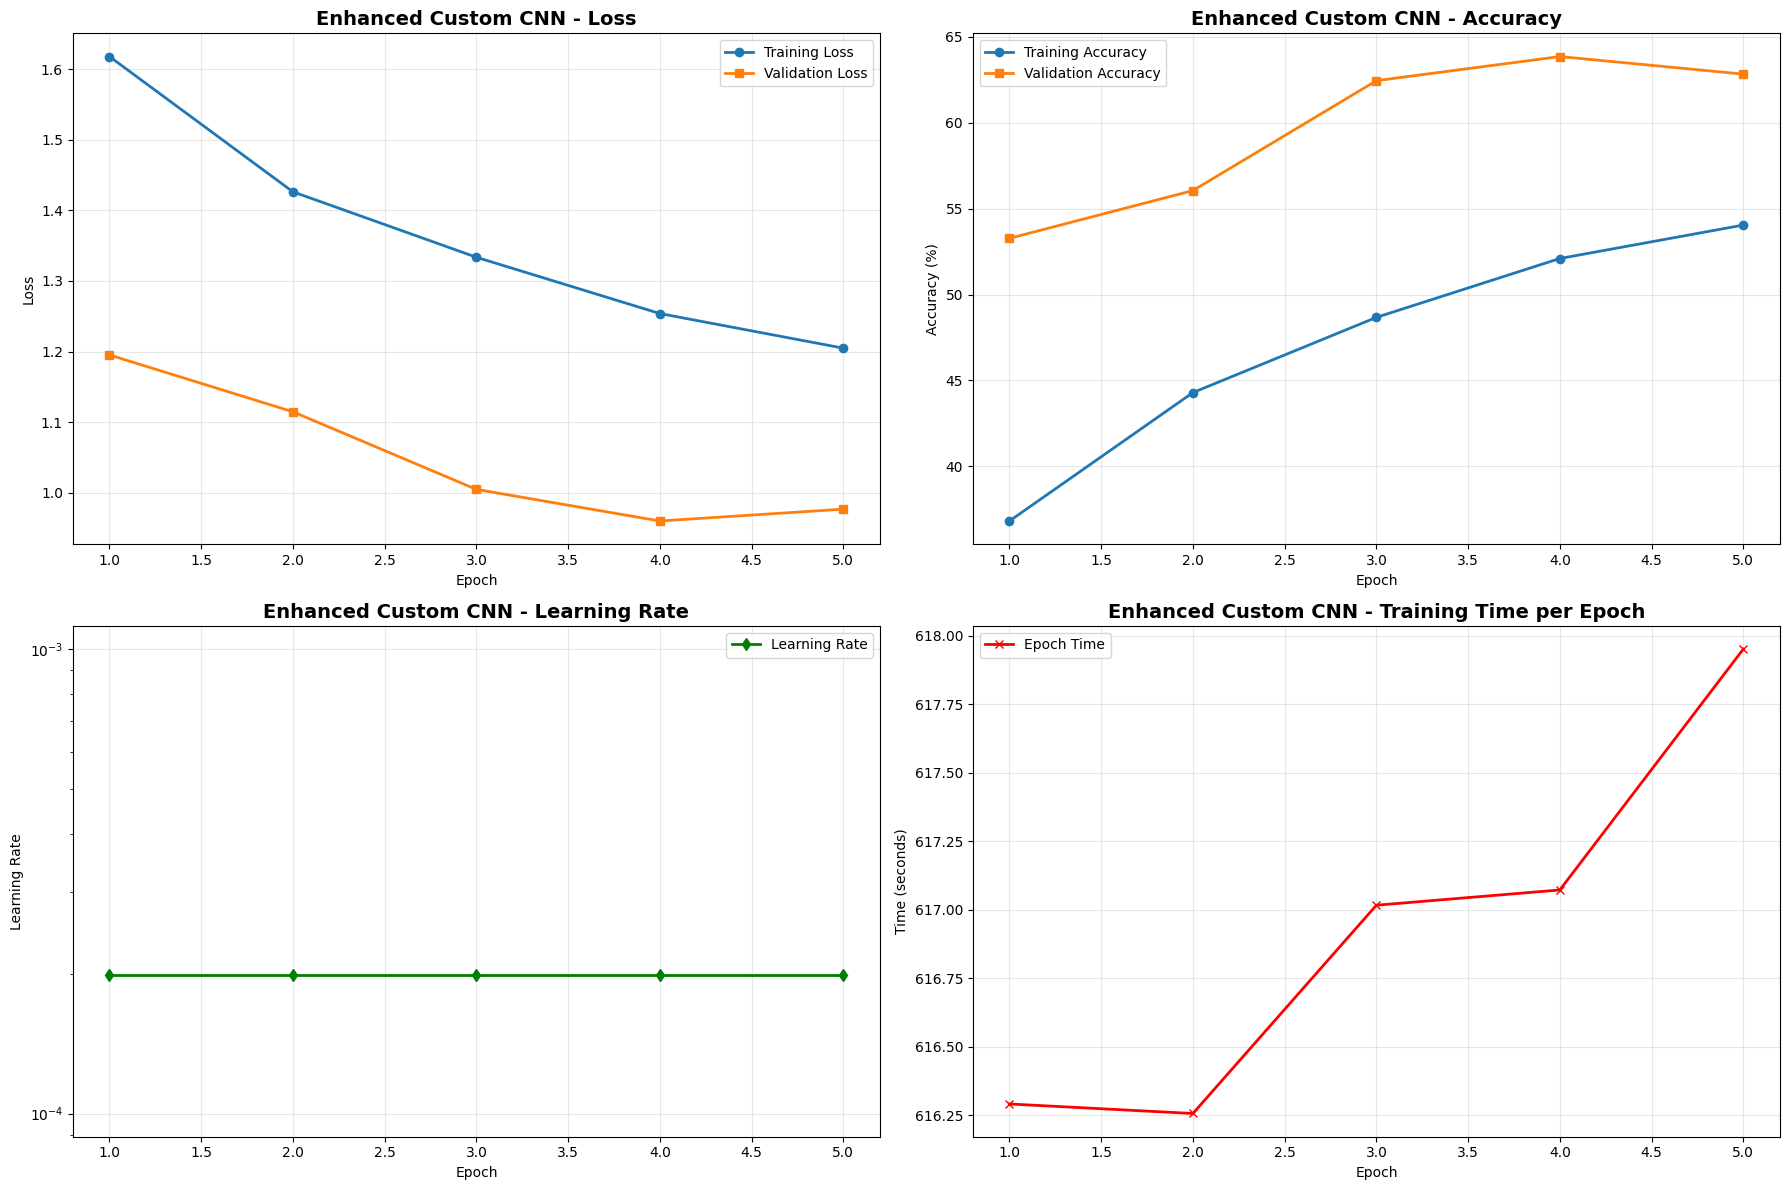


=== Training Summary ===
Best Validation Loss: 0.9597
Best Validation Accuracy: 63.86%
Average Epoch Time: 616.92 seconds
Total Training Time: 3084.59 seconds


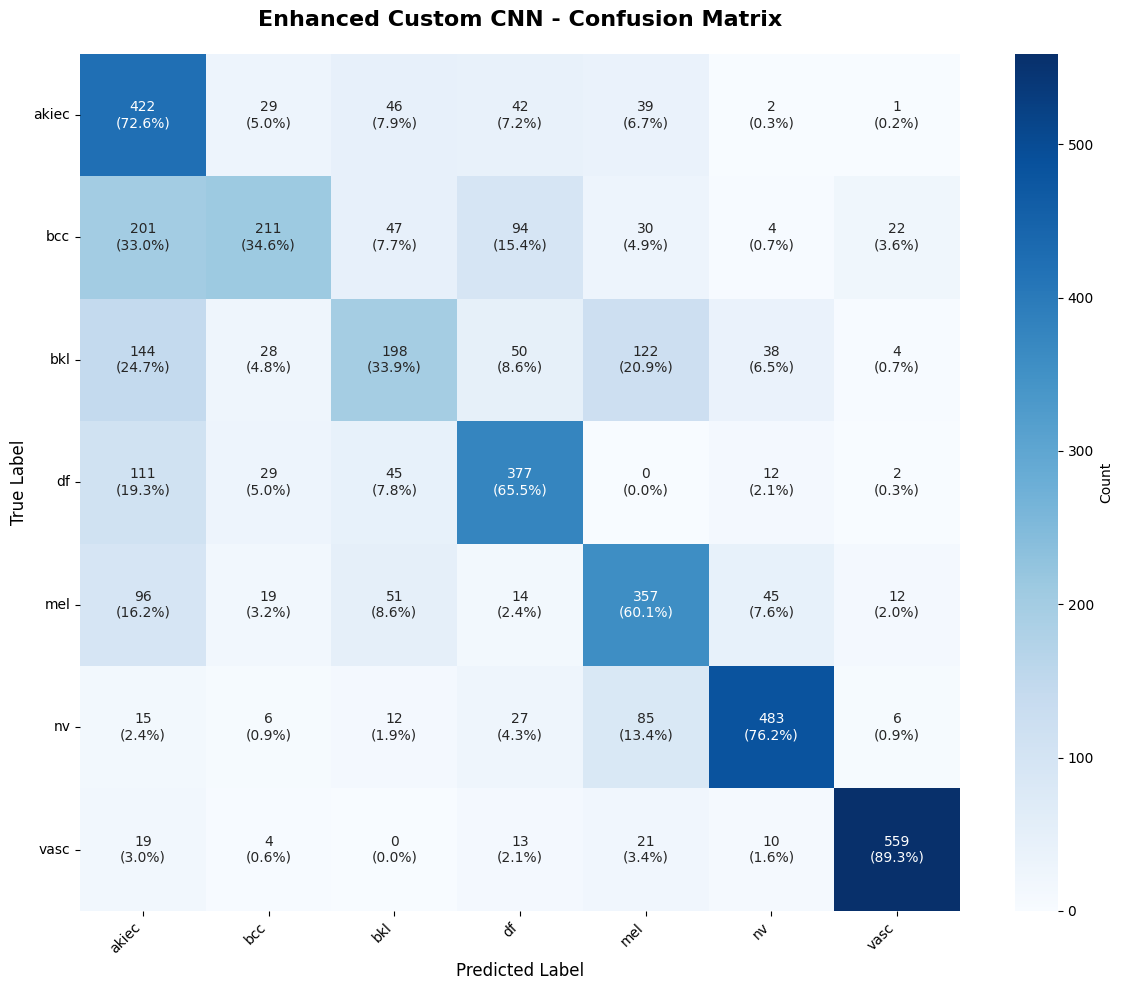

In [41]:

# Plot results for custom model
plot_enhanced_training_history(custom_history, "Enhanced Custom CNN")
plot_confusion_matrix(custom_metrics['confusion_matrix'], class_names,
                      "Enhanced Custom CNN - Confusion Matrix")


In [42]:

# Step 4: Train enhanced pretrained models
print("\n" + "=" * 60)
print("STEP 4: TRAINING ENHANCED PRETRAINED MODELS")
print("=" * 60)



STEP 4: TRAINING ENHANCED PRETRAINED MODELS


In [43]:

#pretrained_models = ['resnet', 'vgg', 'mobilenet']
pretrained_models = ['mobilenet']
model_results = {
    'enhanced_custom': {
        'model': custom_model,
        'metrics': custom_metrics,
        'history': custom_history
    }
}



Training Enhanced MOBILENET model...
=== Training Enhanced MOBILENET Model ===
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 114MB/s] 

Training model for 10 epochs with enhanced dataset...
Training samples per epoch: 39228
Validation samples: 4203


Epoch 1/10, Batch 0/1226, Loss: 2.2836, Acc: 15.62%
Epoch 1/10, Batch 100/1226, Loss: 0.9529, Acc: 41.12%
Epoch 1/10, Batch 200/1226, Loss: 1.6319, Acc: 50.19%
Epoch 1/10, Batch 300/1226, Loss: 0.6887, Acc: 55.15%
Epoch 1/10, Batch 400/1226, Loss: 1.1489, Acc: 58.32%
Epoch 1/10, Batch 500/1226, Loss: 0.9726, Acc: 60.57%
Epoch 1/10, Batch 600/1226, Loss: 0.9917, Acc: 62.45%
Epoch 1/10, Batch 700/1226, Loss: 0.7408, Acc: 64.00%
Epoch 1/10, Batch 800/1226, Loss: 0.8025, Acc: 65.32%
Epoch 1/10, Batch 900/1226, Loss: 0.7450, Acc: 66.53%
Epoch 1/10, Batch 1000/1226, Loss: 0.7558, Acc: 67.63%
Epoch 1/10, Batch 1100/1226, Loss: 0.7349, Acc: 68.59%
Epoch 1/10, Batch 1200/1226, Loss: 0.6026, Acc: 69.38%
Epoch 1/10:
Train Loss: 0.8279, Train Acc: 69.54%
Val Loss: 0.4174, Val Acc: 84.61%
Learning Rate: 0.000198, Epoch Time: 156.96s
----------------------------------------------------------------------
New best model saved! Val Loss: 0.4174, Val Acc: 84.61%
Epoch 2/10, Batch 0/1226, Loss: 0.4087, A

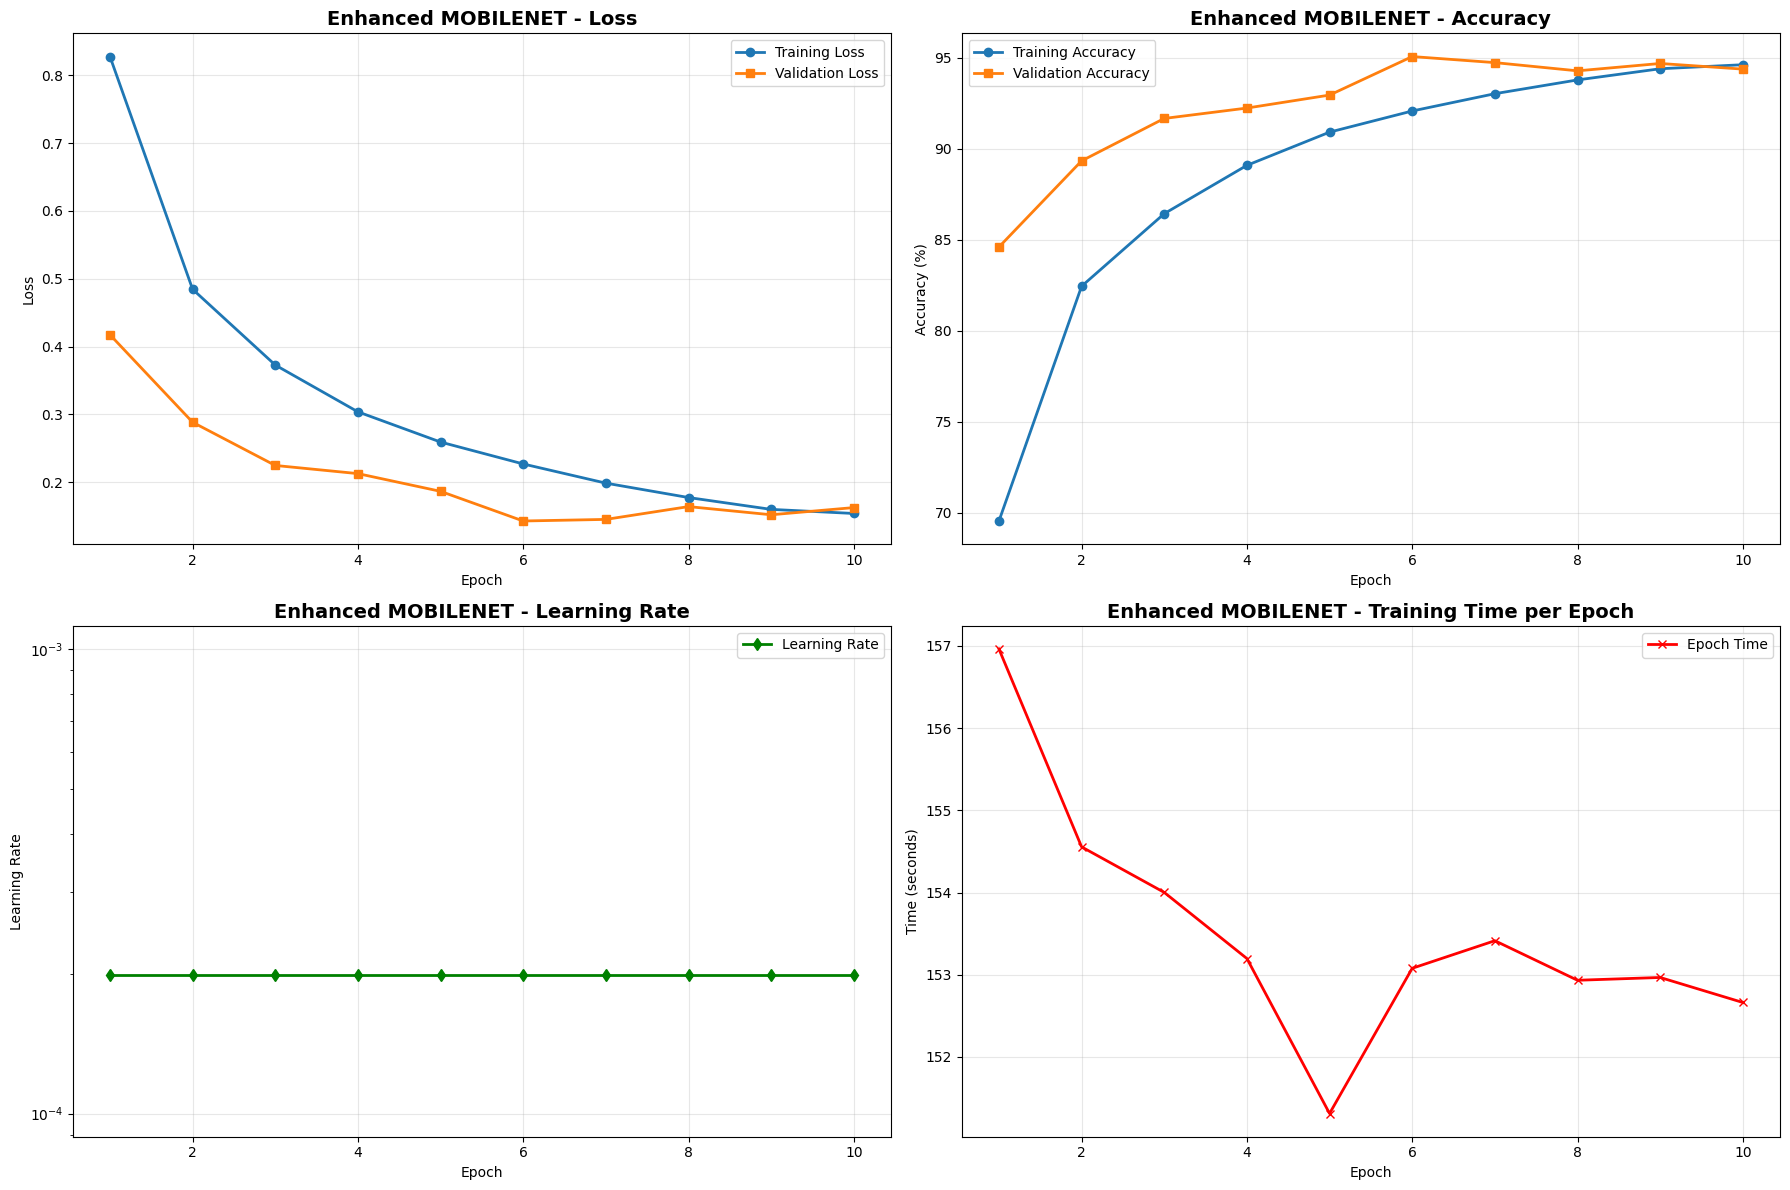


=== Training Summary ===
Best Validation Loss: 0.1425
Best Validation Accuracy: 95.07%
Average Epoch Time: 153.51 seconds
Total Training Time: 1535.08 seconds


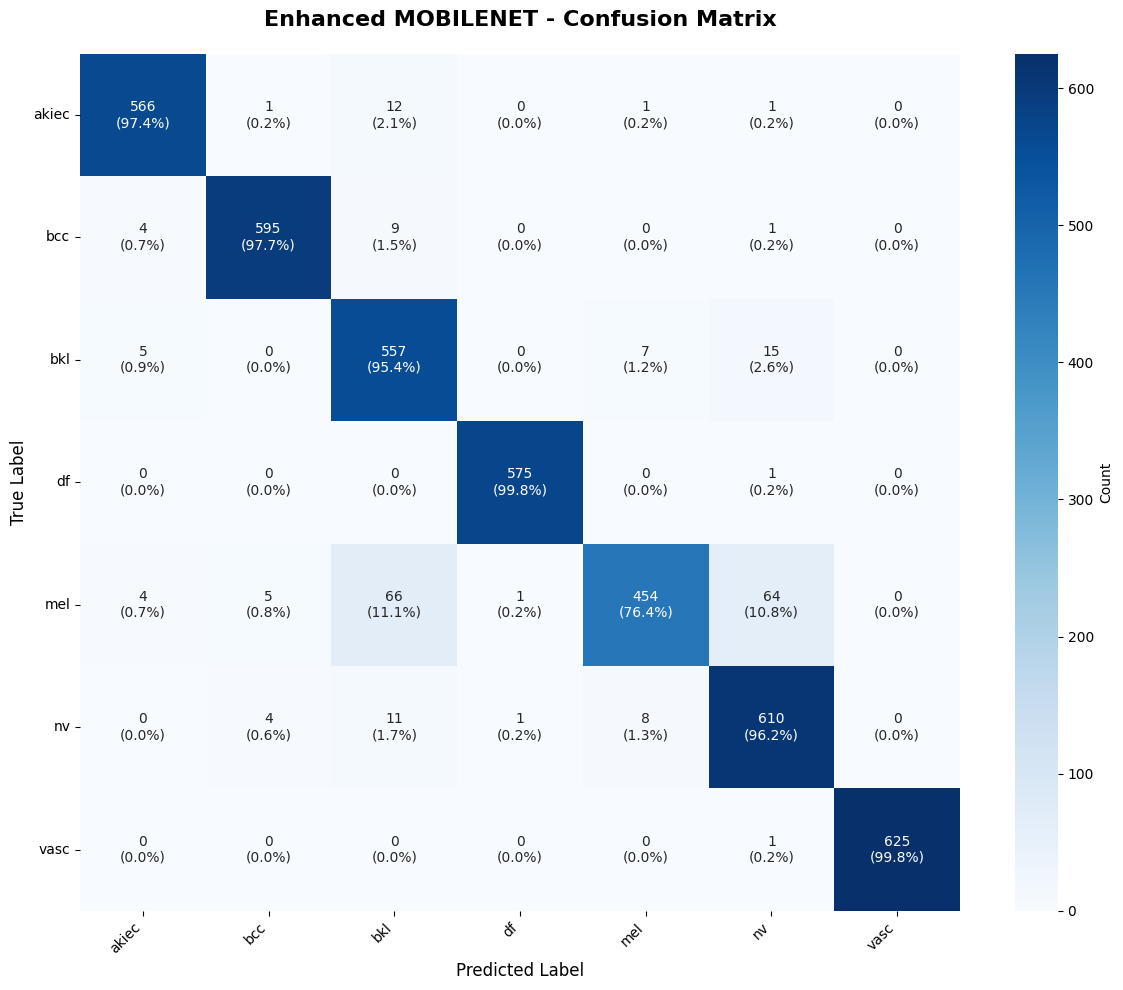

In [44]:

for model_name in pretrained_models:
    print(f"\nTraining Enhanced {model_name.upper()} model...")
    model, history, metrics = train_enhanced_pretrained_model(
        model_name, train_loader, val_loader, test_loader, DEVICE, class_names, best_params
    )

    model_results[f'enhanced_{model_name}'] = {
        'model': model,
        'metrics': metrics,
        'history': history
    }

    # Plot results
    plot_enhanced_training_history(history, f"Enhanced {model_name.upper()}")
    plot_confusion_matrix(metrics['confusion_matrix'], class_names,
                          f"Enhanced {model_name.upper()} - Confusion Matrix")


In [45]:

# Step 5: Enhanced model comparison
print("\n" + "=" * 60)
print("STEP 5: ENHANCED MODEL COMPARISON AND SELECTION")
print("=" * 60)



STEP 5: ENHANCED MODEL COMPARISON AND SELECTION


In [46]:

print("Enhanced Model Performance Summary:")
print("-" * 100)
print(f"{'Model':<20} {'Accuracy':<12} {'F1-Macro':<12} {'Precision':<12} {'Recall':<12} {'Best Val Acc':<12}")
print("-" * 100)

best_model_name = None
best_f1_score = 0


for model_name, results in model_results.items():
    metrics = results['metrics']
    history = results['history']

    accuracy = metrics['accuracy']
    f1_macro = metrics['f1_macro']
    precision = metrics['precision_macro']
    recall = metrics['recall_macro']
    best_val_acc = history['best_val_acc']

    print(f"{model_name.upper():<20} {accuracy:<12.4f} {f1_macro:<12.4f} {precision:<12.4f} {recall:<12.4f} {best_val_acc:<12.2f}")

    if f1_macro > best_f1_score:
        best_f1_score = f1_macro
        best_model_name = model_name


Enhanced Model Performance Summary:
----------------------------------------------------------------------------------------------------
Model                Accuracy     F1-Macro     Precision    Recall       Best Val Acc
----------------------------------------------------------------------------------------------------
ENHANCED_CUSTOM      0.6201       0.6119       0.6364       0.6175       63.86       
ENHANCED_MOBILENET   0.9472       0.9464       0.9506       0.9469       95.07       


In [47]:

print("-" * 100)
print(f"Best Model: {best_model_name.upper()} (Macro F1-Score: {best_f1_score:.4f})")


----------------------------------------------------------------------------------------------------
Best Model: ENHANCED_MOBILENET (Macro F1-Score: 0.9464)


In [48]:

# Step 6: Save the best model
print("\n" + "=" * 60)
print("STEP 6: SAVING THE BEST MODEL")
print("=" * 60)

best_model = model_results[best_model_name]['model']
best_metrics = model_results[best_model_name]['metrics']

save_enhanced_model(best_model, best_model_name, best_metrics, best_params)



STEP 6: SAVING THE BEST MODEL
Enhanced model saved to: ./enhanced_saved_models/best_enhanced_enhanced_mobilenet_model.pth
Model info saved to: ./enhanced_saved_models/best_enhanced_enhanced_mobilenet_info.json



STEP 7: COMPREHENSIVE PERFORMANCE ANALYSIS


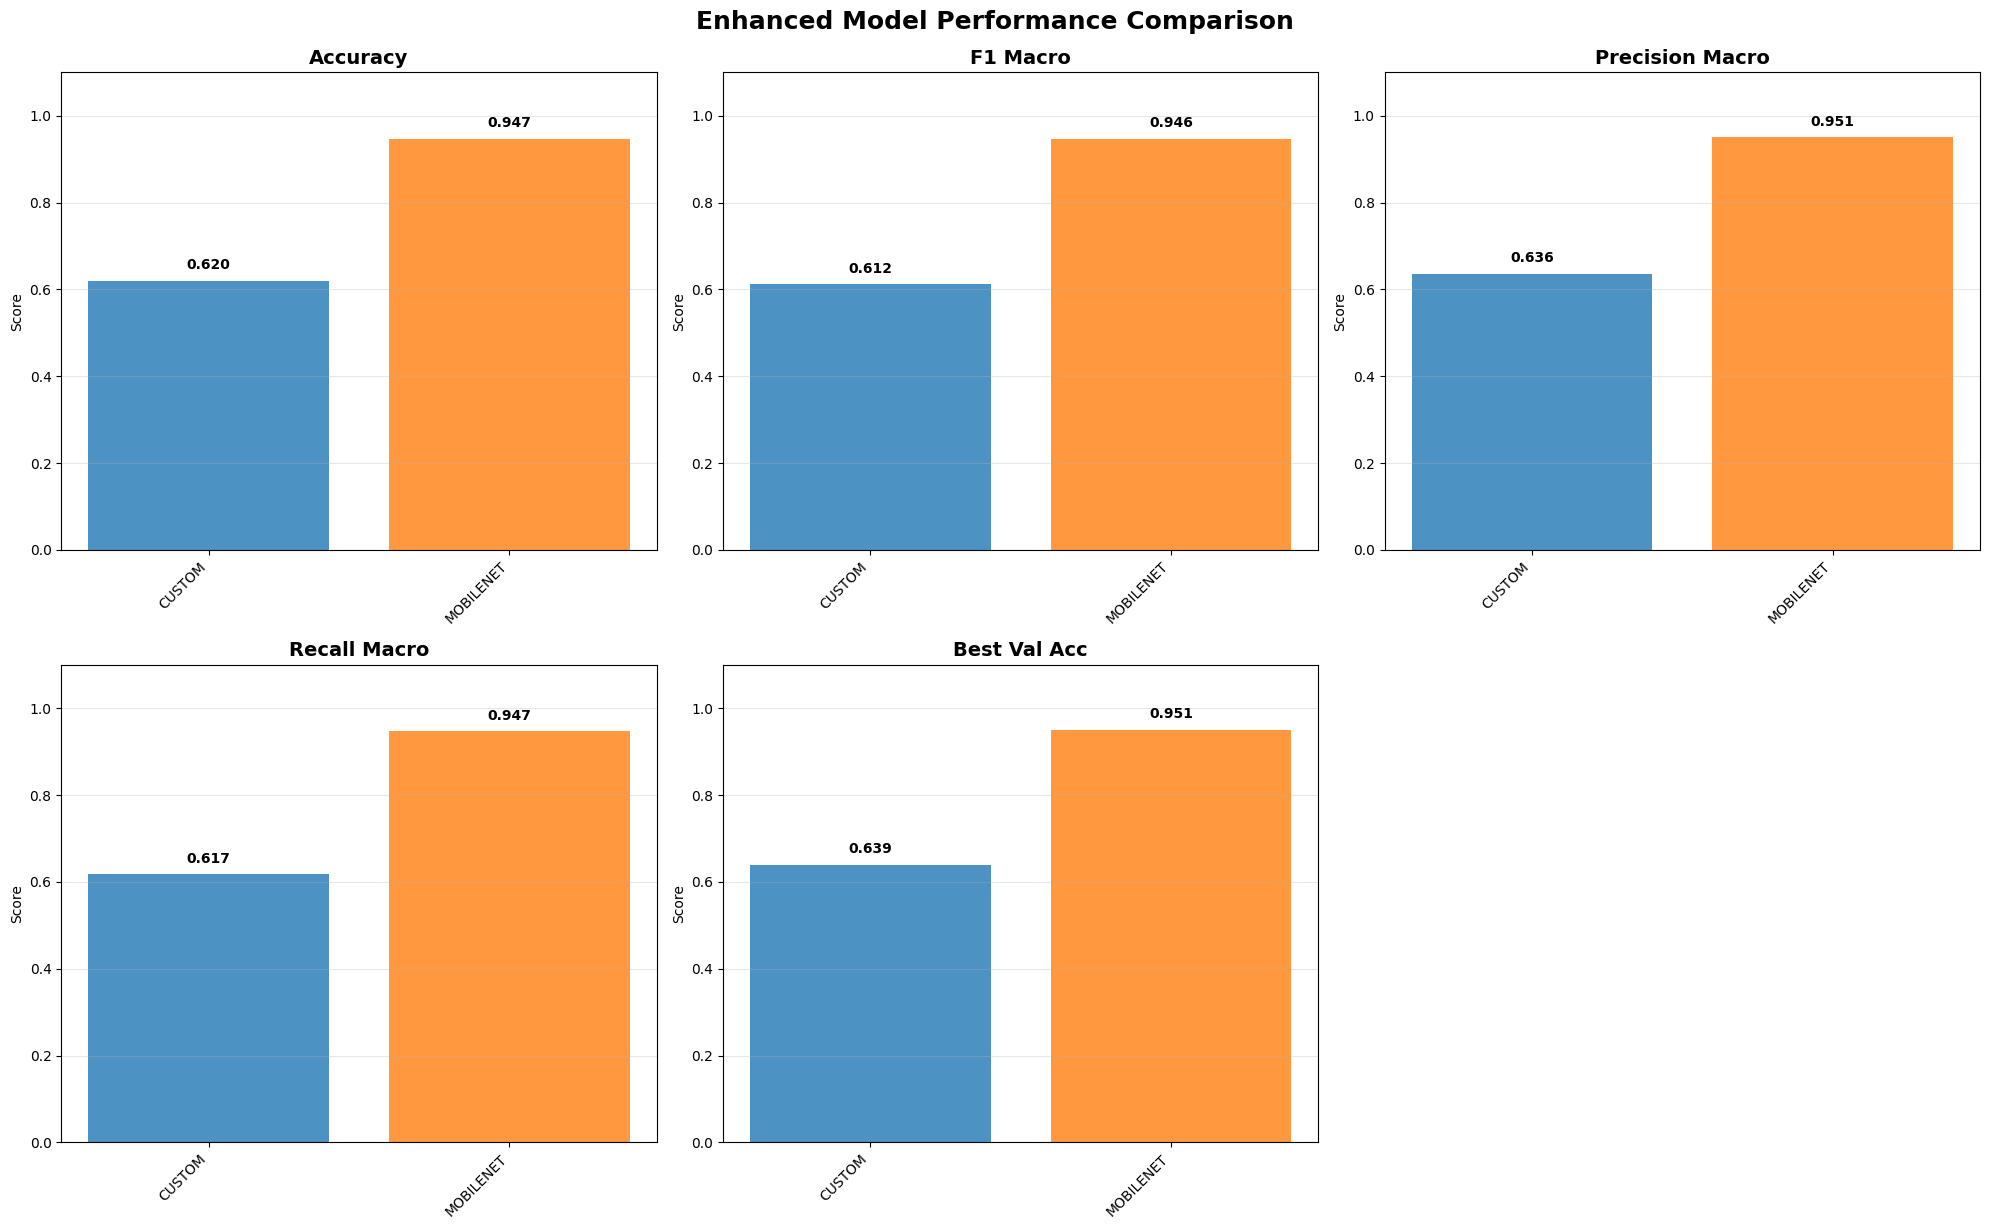


=== Detailed Model Comparison ===

ENHANCED_CUSTOM:
  Test Accuracy: 0.6201 (62.01%)
  Best Val Accuracy: 63.86%
  F1-Score (Macro): 0.6119
  Precision (Macro): 0.6364
  Recall (Macro): 0.6175
  Training Time: 3084.6 seconds

ENHANCED_MOBILENET:
  Test Accuracy: 0.9472 (94.72%)
  Best Val Accuracy: 95.07%
  F1-Score (Macro): 0.9464
  Precision (Macro): 0.9506
  Recall (Macro): 0.9469
  Training Time: 1535.1 seconds


In [49]:

# Step 7: Create comprehensive performance analysis
print("\n" + "=" * 60)
print("STEP 7: COMPREHENSIVE PERFORMANCE ANALYSIS")
print("=" * 60)

create_enhanced_performance_analysis(model_results)


In [50]:

# Step 8: Enhanced model testing demonstration
print("\n" + "=" * 60)
print("STEP 8: ENHANCED MODEL TESTING DEMONSTRATION")
print("=" * 60)

print("Enhanced testing functionality is ready!")
print("To test on a single image with detailed analysis, use:")
print("test_single_image_enhanced(best_model, 'path_to_test_image.jpg', class_names, DEVICE)")

results = {
    'best_model_name': best_model_name,
    'best_model': best_model,
    'model_results': model_results,
    'class_names': class_names,
    'device': DEVICE,
    'best_params': best_params,
    'augmentation_factor': AUGMENTATION_FACTOR
}




STEP 8: ENHANCED MODEL TESTING DEMONSTRATION
Enhanced testing functionality is ready!
To test on a single image with detailed analysis, use:
test_single_image_enhanced(best_model, 'path_to_test_image.jpg', class_names, DEVICE)




# 10. EXECUTION


In [51]:

print("\n" + "=" * 90)
print("ENHANCED PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 90)



ENHANCED PIPELINE COMPLETED SUCCESSFULLY!


In [52]:

print(f"\nBest Model: {results['best_model_name'].upper()}")
print(f"Augmentation Factor: {results['augmentation_factor']}")
print("All enhanced models have been trained, evaluated, and compared.")
print("The best model has been saved with comprehensive information.")



Best Model: ENHANCED_MOBILENET
Augmentation Factor: 1
All enhanced models have been trained, evaluated, and compared.
The best model has been saved with comprehensive information.


In [53]:

print(f"\nDataset Summary:")
train_size = len(results['model_results'][results['best_model_name']]['history']['train_losses'])
print(f"  Classes: {len(results['class_names'])}")
print(f"  Training epochs: {train_size}")
print(f"  Augmentation: On-the-fly (memory-based)")



Dataset Summary:
  Classes: 7
  Training epochs: 10
  Augmentation: On-the-fly (memory-based)


In [54]:
def test_files(test_loader):
    """Quick function to get all test file paths"""
    return [test_loader.dataset.images[i] for i in range(10)]

test_files(test_loader)

['/content/dataset/SkinData/mel/ISIC_0033546.jpg',
 '/content/dataset/SkinData/mel/_1051_6934209.jpg',
 '/content/dataset/SkinData/nv/ISIC_0027206.jpg',
 '/content/dataset/SkinData/nv/ISIC_0028798.jpg',
 '/content/dataset/SkinData/df/_103_9621630.jpg',
 '/content/dataset/SkinData/nv/ISIC_0028534.jpg',
 '/content/dataset/SkinData/mel/_398_3860557.jpg',
 '/content/dataset/SkinData/nv/ISIC_0024320.jpg',
 '/content/dataset/SkinData/mel/_569_1538414.jpg',
 '/content/dataset/SkinData/bkl/ISIC_0031903.jpg']

In [56]:

print(f"\nTo test on new images with enhanced analysis:")

test_images = test_files(test_loader)
for img in test_images:
  output = test_single_image_enhanced(
      results['best_model'],
      img,
      results['class_names'],
      results['device']
  )
  print("Prediction result:", output)


To test on new images with enhanced analysis:
=== Enhanced Image Analysis ===
Image: /content/dataset/SkinData/mel/ISIC_0033546.jpg
Original Size: (600, 450)
Predicted Class: nv
Confidence: 0.6473 (64.73%)
Confidence Level: Medium

All Class Probabilities:
  akiec: 0.0004 (0.04%)
  bcc: 0.0001 (0.01%)
  bkl: 0.0003 (0.03%)
  df: 0.0011 (0.11%)
  mel: 0.3503 (35.03%)
  nv: 0.6473 (64.73%)
  vasc: 0.0004 (0.04%)

Top-3 Predictions:
  1. nv: 0.6473 (64.73%)
  2. mel: 0.3503 (35.03%)
  3. df: 0.0011 (0.11%)
Prediction result: {'predicted_class': 'nv', 'confidence': 0.6473369002342224, 'confidence_level': 'Medium', 'all_probabilities': [0.00044251259532757103, 7.908760744612664e-05, 0.000297533260891214, 0.0011273787822574377, 0.3503480553627014, 0.6473369002342224, 0.0003685233823489398], 'top3_predictions': [('nv', 0.6473369002342224), ('mel', 0.3503480553627014), ('df', 0.0011273787822574377)], 'original_size': (600, 450)}
=== Enhanced Image Analysis ===
Image: /content/dataset/SkinData